# QAOA for Maximum Cut — Part I: Theory

**Physics 565/656 · Spring 2026 · Sehong Park**

This notebook develops the mathematical foundations of QAOA for the MaxCut problem:
the problem formulation, the quantum circuit ansatz, the variational objective,
and the analytic $p=1$ solution for cycle graphs.


---
## 1. The MaxCut Problem

**Definition.** Given an undirected graph $G = (V, E)$ with $n = |V|$ nodes,
find a partition $(S, \bar{S})$ of $V$ that maximizes the number of crossing edges:

$$\text{MaxCut}(S) = |\{(i,j)\in E : i\in S,\ j\in\bar{S}\}|
= \sum_{(i,j)\in E} \frac{1 - z_i z_j}{2}, \quad z_i \in \{-1,+1\}.$$

**Complexity.** MaxCut is NP-hard (Karp, 1972).
The solution space has size $2^n / 2 = 2^{n-1}$ (by symmetry of the partition).

**Quantum encoding.** Replace spin variables $z_i \in \{-1,+1\}$ with Pauli-$Z$ operators
$\hat{Z}_i$ acting on qubit $i$, giving the **cost Hamiltonian**:

$$H_C = \frac{1}{2}\sum_{(i,j)\in E}(I - Z_i Z_j).$$

$H_C$ is diagonal in the computational basis: for a bitstring $x \in \{0,1\}^n$,

$$H_C|x\rangle = \underbrace{\text{cut}(x)}_{\text{number of crossing edges}}\cdot|x\rangle.$$

Finding $\text{MaxCut}$ is equivalent to finding the ground state of $-H_C$.


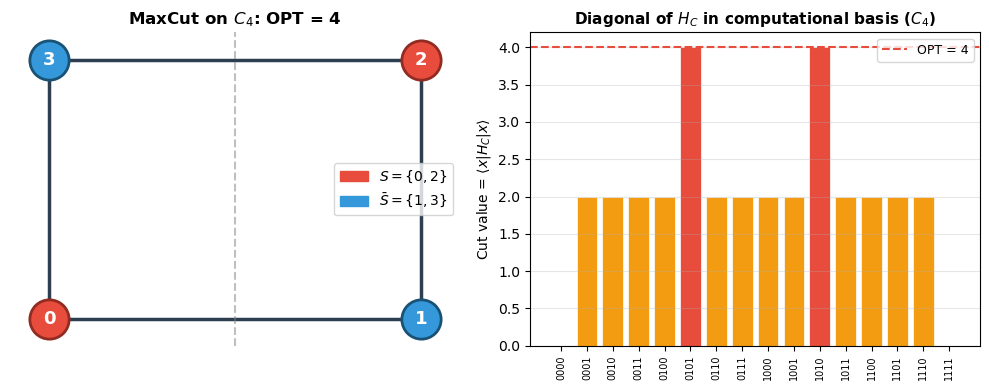

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Example: C4 ───────────────────────────────────────────────────
G_c4 = nx.cycle_graph(4)
pos  = {0:(0,0), 1:(1,0), 2:(1,1), 3:(0,1)}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: graph
ax = axes[0]
nx.draw_networkx_nodes(G_c4, pos, nodelist=[0,2], ax=ax,
    node_color='#E74C3C', node_size=800, edgecolors='#922B21', linewidths=2)
nx.draw_networkx_nodes(G_c4, pos, nodelist=[1,3], ax=ax,
    node_color='#3498DB', node_size=800, edgecolors='#1A5276', linewidths=2)
nx.draw_networkx_edges(G_c4, pos, ax=ax, edge_color='#2C3E50', width=2.5)
nx.draw_networkx_labels(G_c4, pos, ax=ax, font_color='white', font_size=13, font_weight='bold')
ax.axvline(x=0.5, color='gray', ls='--', lw=1.5, alpha=0.5)
p1 = mpatches.Patch(color='#E74C3C', label=r'$S = \{0,2\}$')
p2 = mpatches.Patch(color='#3498DB', label=r'$\bar{S} = \{1,3\}$')
ax.legend(handles=[p1,p2], fontsize=10)
ax.set_title(r'MaxCut on $C_4$: OPT = 4', fontsize=12, fontweight='bold')
ax.axis('off')

# Right: H_C diagonal
ax2 = axes[1]
n = 4; edges = [(0,1),(1,2),(2,3),(0,3)]
cut_vals = [sum(1 for i,j in edges if ((x>>i)&1) != ((x>>j)&1)) for x in range(16)]
labels = [f'{x:04b}' for x in range(16)]
colors = ['#E74C3C' if v == 4 else ('#F39C12' if v == 2 else '#BDC3C7') for v in cut_vals]
ax2.bar(range(16), cut_vals, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(16)); ax2.set_xticklabels(labels, rotation=90, fontsize=7)
ax2.set_ylabel(r'Cut value = $\langle x | H_C | x \rangle$', fontsize=10)
ax2.set_title(r'Diagonal of $H_C$ in computational basis ($C_4$)', fontsize=11, fontweight='bold')
ax2.axhline(4, color='#E74C3C', ls='--', lw=1.5, label='OPT = 4')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('theory_maxcut.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 2. The QAOA Ansatz

### 2.1 Circuit Structure

QAOA (Farhi, Goldstone, Gutmann 2014) approximates the ground state of $H_C$
via a variational quantum circuit with $p$ layers:

$$|\psi_p(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle
= \underbrace{e^{-i\beta_p H_B}e^{-i\gamma_p H_C}}_{\text{layer }p}
\cdots
\underbrace{e^{-i\beta_1 H_B}e^{-i\gamma_1 H_C}}_{\text{layer }1}
|{+}\rangle^{\otimes n}$$

where $|{+}\rangle^{\otimes n} = H^{\otimes n}|0\rangle^{\otimes n}$ is the uniform superposition.

**Cost unitary** $U_C(\gamma_k) = e^{-i\gamma_k H_C}$:
Since $H_C$ is diagonal with eigenvalues $\text{cut}(x)$, this is a phase oracle:
$$U_C(\gamma)|x\rangle = e^{-i\gamma\,\text{cut}(x)}|x\rangle.$$
Implemented as $|E|$ commuting $RZZ$ gates: $\text{CX} \cdot RZ(2\gamma) \cdot \text{CX}$ per edge.

**Mixer unitary** $U_B(\beta_k) = e^{-i\beta_k H_B}$, $H_B = \sum_i X_i$:
Separable across qubits — $U_B(\beta) = \bigotimes_i e^{-i\beta X_i}$,
implemented as $RX(2\beta)$ on each qubit.

### 2.2 Variational Objective

The optimization problem is:

$$\max_{\boldsymbol{\gamma},\boldsymbol{\beta}}
F_p(\boldsymbol{\gamma},\boldsymbol{\beta})
= \langle\psi_p(\boldsymbol{\gamma},\boldsymbol{\beta})|H_C|\psi_p(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle.$$

Parameters are optimized by a classical optimizer (COBYLA or SPSA),
completing the hybrid quantum-classical loop.

### 2.3 Key Theoretical Properties

**Monotonicity:** $F_p^* \leq F_{p+1}^*$ — adding layers never hurts.

**Completeness:** $F_p^* \to \text{OPT}$ as $p \to \infty$ (adiabatic theorem).

**$p=1$ guarantee on triangle-free graphs (Farhi et al. 2014):**
$$F_1^* / \text{OPT} \geq \frac{3\sqrt{3}-3}{8} \approx 0.6924.$$

**Total cost on real hardware:** $O(T \cdot S \cdot p|E|)$,
where $T$ = optimizer iterations, $S$ = shots per evaluation.


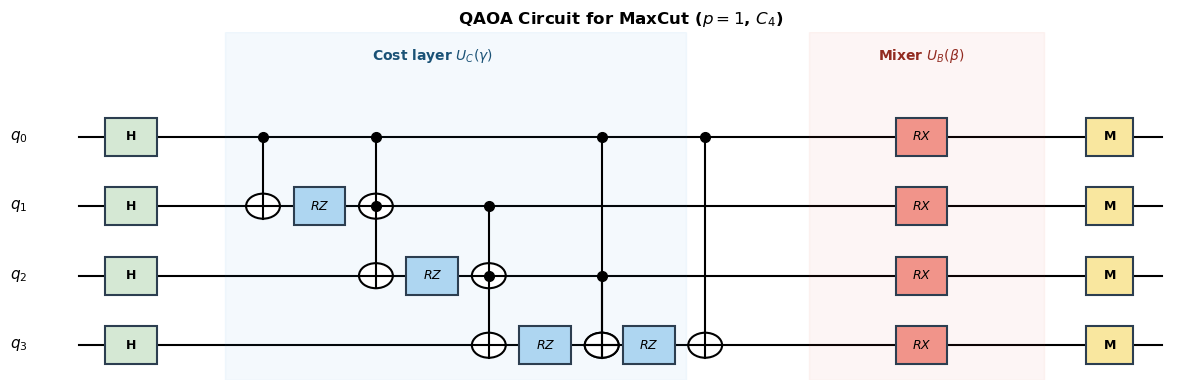

In [4]:
# ── QAOA circuit schematic (p=1, C4) ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 12); ax.set_ylim(-0.5, 4.5)
ax.axis('off')
ax.set_title(r'QAOA Circuit for MaxCut ($p=1$, $C_4$)', fontsize=12, fontweight='bold')

qubits = [r'$q_0$', r'$q_1$', r'$q_2$', r'$q_3$']
y_pos  = [3, 2, 1, 0]
colors_q = ['#E74C3C','#3498DB','#2ECC71','#F39C12']

# Qubit lines
for y in y_pos:
    ax.axhline(y, xmin=0.02, xmax=0.98, color='black', lw=1.5, zorder=1)

# Labels
for label, y in zip(qubits, y_pos):
    ax.text(-0.3, y, label, ha='right', va='center', fontsize=11)

def gate_box(ax, x, y, label, color='#AED6F1', width=0.55, height=0.55):
    rect = plt.Rectangle((x-width/2, y-height/2), width, height,
                          facecolor=color, edgecolor='#2C3E50', linewidth=1.5, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=9, fontweight='bold', zorder=4)

def cnot(ax, x, ctrl, tgt):
    ax.plot([x, x], [ctrl, tgt], 'k-', lw=1.5, zorder=2)
    ax.plot(x, ctrl, 'ko', ms=7, zorder=3)
    circle = plt.Circle((x, tgt), 0.18, color='white', ec='black', lw=1.5, zorder=3)
    ax.add_patch(circle)
    ax.plot([x-0.18, x+0.18], [tgt, tgt], 'k-', lw=1.5, zorder=4)
    ax.plot([x, x], [tgt-0.18, tgt+0.18], 'k-', lw=1.5, zorder=4)

# H gates
for y in y_pos:
    gate_box(ax, 0.8, y, 'H', color='#D5E8D4')

# Cost layer: 4 edges (0,1),(1,2),(2,3),(0,3)
cx_positions = [(2.2, 3, 2), (3.4, 2, 1), (4.6, 1, 0), (5.8, 3, 0)]
rz_x_positions = [2.8, 4.0, 5.2, 6.3]

ax.text(4.0, 4.1, r'Cost layer $U_C(\gamma)$', ha='center', fontsize=10,
        color='#1A5276', fontweight='bold')
ax.axvspan(1.8, 6.7, alpha=0.05, color='#3498DB')

for (cx_x, c, t), rz_x in zip(cx_positions, rz_x_positions):
    cnot(ax, cx_x, c, t)
    gate_box(ax, rz_x, t, r'$RZ$', color='#AED6F1')
    cnot(ax, rz_x + 0.6, c, t)

# Mixer layer
ax.text(9.2, 4.1, r'Mixer $U_B(\beta)$', ha='center', fontsize=10,
        color='#922B21', fontweight='bold')
ax.axvspan(8.0, 10.5, alpha=0.05, color='#E74C3C')
for y in y_pos:
    gate_box(ax, 9.2, y, r'$RX$', color='#F1948A')

# Measure
for y in y_pos:
    gate_box(ax, 11.2, y, 'M', color='#F9E79F', width=0.5)

plt.tight_layout()
plt.savefig('theory_circuit.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 3. Analytic $p=1$ Solution for Cycle Graphs

For $p=1$ on a 2-regular (cycle) graph $C_n$,
the expectation value has a closed form.
Starting from $|+\rangle^{\otimes n}$:

$$F_1(\gamma,\beta) = 2 + \sin(4\beta)\sin(2\gamma) \qquad (C_4)$$

More generally, for any triangle-free graph with all degrees $d$:

$$F_1(\gamma,\beta) = \frac{|E|}{2}
+ \frac{\sin(4\beta)}{2}\sum_{(u,v)\in E}\sin(\gamma)
\Bigl[\cos^{d-1}(\gamma) + \cos^{d-1}(\gamma)\Bigr].$$

For $C_n$ (all degrees $d=2$, no triangles, no shared neighbours):

$$F_1(\gamma,\beta) = \frac{n}{2} + \sin(4\beta)\sin(\gamma)\cos(\gamma)
= \frac{n}{2} + \frac{1}{2}\sin(4\beta)\sin(2\gamma).$$

**Global maximum** at $\beta^* = \pi/8$, $\gamma^* = \pi/4$:

$$F_1^* = \frac{n}{2} + \frac{1}{2}, \quad
\alpha^* = \frac{F_1^*}{\text{OPT}} = \frac{n/2 + 1/2}{n/2} = 1 + \frac{1}{n} \xrightarrow{n\to\infty} 1.$$

Wait — for $C_n$ the OPT is $n/2$ (alternating cut), so $\alpha^* = (n/2 + 1/2)/(n/2)$... 
Actually for $C_n$ with $n$ even: $\text{OPT} = n$ (all edges can be cut).
Let us verify numerically.


C4 analytic vs statevector: max error = 2.66e-15
Optimal at (γ*=π/4, β*=π/8): F1 = 3.00000000
Analytic:                     F1 = 3.00000000
Approximation ratio: 0.750000


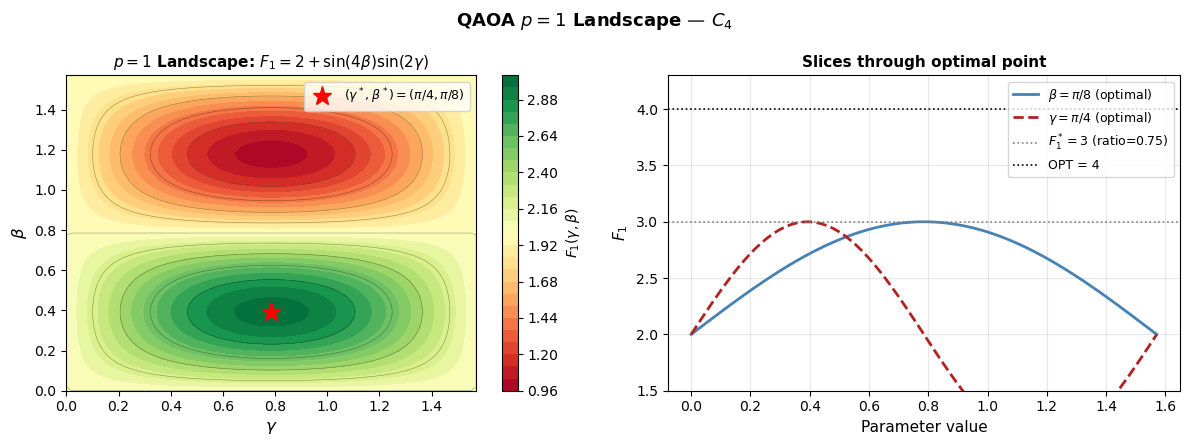

In [6]:
# ── Analytic p=1 verification ─────────────────────────────────────
from scipy.linalg import expm

I2 = np.eye(2, dtype=complex)
Z  = np.array([[1,0],[0,-1]], dtype=complex)
X  = np.array([[0,1],[1,0]], dtype=complex)

def kron_n(ops):
    out = ops[0]
    for m in ops[1:]: out = np.kron(out, m)
    return out

def apply_UB_exact(psi, beta, n):
    c, s = np.cos(beta), np.sin(beta)
    for q in range(n):
        psi = psi.reshape([2]*n); psi = np.moveaxis(psi,q,0).reshape(2,-1)
        psi = np.array([c*psi[0]-1j*s*psi[1], -1j*s*psi[0]+c*psi[1]])
        psi = psi.reshape([2]*n); psi = np.moveaxis(psi,0,q)
    return psi.reshape(-1)

def sv_energy(gamma, beta, diag_HC, n):
    DIM = 2**n
    psi = np.ones(DIM, dtype=complex) / np.sqrt(DIM)
    psi = np.exp(-1j * gamma * diag_HC) * psi
    psi = apply_UB_exact(psi, beta, n)
    return np.real(np.dot(psi.conj(), diag_HC * psi))

n_c4 = 4; e_c4 = [(0,1),(1,2),(2,3),(0,3)]
diag_c4 = np.array([sum(1 for i,j in e_c4 if ((x>>i)&1)!=((x>>j)&1))
                     for x in range(2**n_c4)], dtype=float)

Ng = 80
gammas = np.linspace(0, np.pi/2, Ng)
betas  = np.linspace(0, np.pi/2, Ng)
G_grid, B_grid = np.meshgrid(gammas, betas)

F1_sv = np.array([[sv_energy(g, b, diag_c4, n_c4) for g in gammas] for b in betas])
F1_an = 2 + np.sin(4*B_grid) * np.sin(2*G_grid)

max_err = np.max(np.abs(F1_sv - F1_an))
print(f"C4 analytic vs statevector: max error = {max_err:.2e}")
print(f"Optimal at (γ*=π/4, β*=π/8): F1 = {sv_energy(np.pi/4, np.pi/8, diag_c4, n_c4):.8f}")
print(f"Analytic:                     F1 = {2 + np.sin(4*np.pi/8)*np.sin(2*np.pi/4):.8f}")
print(f"Approximation ratio: {sv_energy(np.pi/4, np.pi/8, diag_c4, n_c4)/4:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Landscape
ax = axes[0]
cf = ax.contourf(G_grid, B_grid, F1_an, levels=25, cmap='RdYlGn')
ax.contour(G_grid, B_grid, F1_an, levels=10, colors='k', linewidths=0.4, alpha=0.4)
plt.colorbar(cf, ax=ax, label=r'$F_1(\gamma,\beta)$')
ax.plot(np.pi/4, np.pi/8, 'r*', ms=14, label=r'$(\gamma^*,\beta^*)=(\pi/4,\pi/8)$')
ax.set_xlabel(r'$\gamma$', fontsize=12); ax.set_ylabel(r'$\beta$', fontsize=12)
ax.set_title(r'$p=1$ Landscape: $F_1 = 2 + \sin(4\beta)\sin(2\gamma)$', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Slices
ax2 = axes[1]
ax2.plot(gammas, 2 + np.sin(4*np.pi/8)*np.sin(2*gammas),
         color='steelblue', lw=2, label=r'$\beta=\pi/8$ (optimal)')
ax2.plot(betas, 2 + np.sin(4*betas)*np.sin(2*np.pi/4),
         color='firebrick', lw=2, ls='--', label=r'$\gamma=\pi/4$ (optimal)')
ax2.axhline(3.0, color='gray', ls=':', lw=1.2, label=r'$F_1^*=3$ (ratio=0.75)')
ax2.axhline(4.0, color='black', ls=':', lw=1.2, label='OPT = 4')
ax2.set_xlabel('Parameter value', fontsize=11)
ax2.set_ylabel(r'$F_1$', fontsize=11)
ax2.set_title('Slices through optimal point', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9); ax2.set_ylim(1.5, 4.3)
ax2.grid(alpha=0.3)

plt.suptitle(r'QAOA $p=1$ Landscape — $C_4$', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('theory_landscape.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 4. Classical Approximation Algorithms

### 4.1 Random Sampling

Assigns each node to $S$ or $\bar{S}$ uniformly at random.
Expected cut: $|E|/2$, giving ratio $0.5$ for any graph.

### 4.2 Greedy Heuristic

Processes nodes in a random order $\sigma$.
Each node $v$ is placed in the side (S or $\bar{S}$) that maximizes
the number of edges already cut:

$$\text{assign } v \text{ to } \arg\max_{a\in\{S,\bar{S}\}}
\left|\{(v,u)\in E : u \text{ already assigned to the other side}\}\right|.$$

Time: $O(|E|)$ per trial, no formal approximation guarantee.

### 4.3 Goemans-Williamson (SDP Relaxation)

**SDP formulation:** Assign unit vectors $\mathbf{v}_i \in \mathbb{R}^n$ to each node.
Maximize $\frac{1}{2}\sum_{(i,j)\in E}(1 - \mathbf{v}_i \cdot \mathbf{v}_j)$
subject to $\|\mathbf{v}_i\|^2 = 1$.

**Rounding:** Sample a random hyperplane $\mathbf{r}$; assign node $i$ to
$S$ if $\mathbf{v}_i \cdot \mathbf{r} \geq 0$, else to $\bar{S}$.

**Guarantee:** Expected ratio $\geq 0.8786 \cdot \text{OPT}$ (best known poly-time).
Complexity: $O(n^{3.5})$ — impractical beyond $n \approx 1000$.


---
## References

- Farhi, Goldstone, Gutmann. "A quantum approximate optimization algorithm." arXiv:1411.4028 (2014).
- Goemans, Williamson. "Improved approximation algorithms for maximum cut." *JACM* 42, 1115–1145 (1995).
- Farhi, Harrow. "Quantum supremacy through the quantum approximate optimization algorithm." arXiv:1602.07674 (2016).
